Data prepared and scaled
LINEAR kernel: 0.977
POLY kernel: 0.895
RBF kernel: 0.977

Tuning RBF kernel...
Best parameters: {'C': 10, 'gamma': 0.01}
Best CV score: 0.967
Test accuracy: 0.988


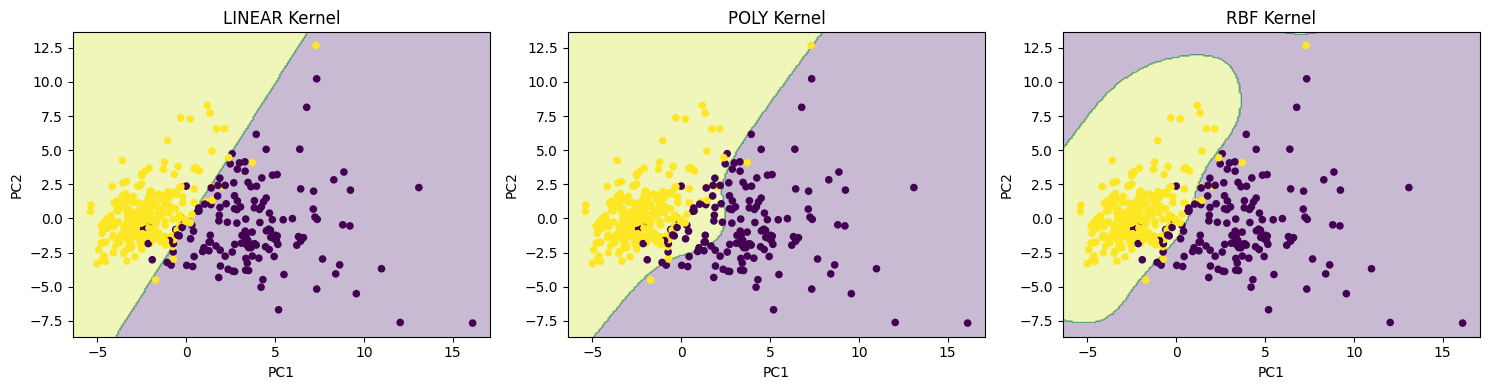

In [1]:
"""
Assignment 6: SVM
Kernel Comparison and GridSearch
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

# Load and prepare data
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale data (important for SVM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data prepared and scaled")

# Train SVM with different kernels
kernels = ['linear', 'poly', 'rbf']
results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[kernel] = acc
    print(f"{kernel.upper()} kernel: {acc:.3f}")

# GridSearchCV for RBF kernel
print("\nTuning RBF kernel...")
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.3f}")
print(f"Test accuracy: {grid.score(X_test_scaled, y_test):.3f}")

# Visualize decision boundaries (2D with PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, kernel in enumerate(kernels):
    svm_2d = SVC(kernel=kernel, random_state=42)
    svm_2d.fit(X_train_pca, y_train)
    
    # Create mesh
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3)
    axes[idx].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=20)
    axes[idx].set_title(f'{kernel.upper()} Kernel')
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('assignment6_svm.png')